In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import sklearn
import imblearn

To save time we will import the preprocessed data using the csv files provided.

In [2]:
Complete_dataset=pd.read_csv('Cleaned_AIS_Dataset.csv')
one_hot=pd.read_csv('One_Hot.csv')
one_hot = one_hot.drop(columns=['Unnamed: 0'])

In [3]:
import torch.nn as nn
Complete_dataset["mmsi"] = Complete_dataset["mmsi"].astype("category").cat.codes
num_vessels = Complete_dataset["mmsi"].nunique()
print(num_vessels)

embedding_dim = 16

#embedding = nn.Embedding(num_vessels, embedding_dim)
#Cleaned up Dataset
mmsi_column=Complete_dataset['mmsi']
sog_column=Complete_dataset['sog']
cog_column=Complete_dataset['cog']
heading_column=Complete_dataset['heading']
length_column=Complete_dataset['length']
width_column=Complete_dataset['width']
draught_column=Complete_dataset['draught']
#Next the navigational status one hot encoding
feature_dataset=pd.concat([sog_column,cog_column,heading_column,length_column,width_column,draught_column,one_hot],axis=1)

3894


In [4]:
shipType=Complete_dataset['shiptype']
print(shipType)
import sklearn as sk
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import TensorDataset, DataLoader

mmsi_data=Complete_dataset['mmsi']
mmsi_encoder = LabelEncoder()
mmsi_encoded = mmsi_encoder.fit_transform(Complete_dataset['mmsi'])
X_mmsi_train, X_mmsi_test, \
X_num_train, X_num_test, \
y_train, y_test = sk.model_selection.train_test_split(
    mmsi_encoded,
    feature_dataset,
    shipType,
    test_size=0.1,
    shuffle=True
)

X_mmsi_train, X_mmsi_val, \
X_num_train, X_num_val, \
y_train, y_val = sk.model_selection.train_test_split(
    X_mmsi_train,
    X_num_train,
    y_train,
    test_size=0.1,
    shuffle=True
)
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc=le.transform(y_test)
#Next we need to feed these into the basic pytorch model

X_mmsi_train_t = torch.tensor(X_mmsi_train, dtype=torch.long)
X_mmsi_val_t   = torch.tensor(X_mmsi_val, dtype=torch.long)
X_mmsi_test_t=torch.tensor(X_mmsi_test,dtype=torch.long)

X_num_train_t = torch.tensor(X_num_train.to_numpy(), dtype=torch.float32)
X_num_val_t   = torch.tensor(X_num_val.to_numpy(), dtype=torch.float32)
X_num_test_t=torch.tensor(X_num_test.to_numpy(),dtype=torch.float32)
y_train_t = torch.tensor(y_train_enc, dtype=torch.long)
y_val_t   = torch.tensor(y_val_enc, dtype=torch.long)
y_test_t=torch.tensor(y_test_enc,dtype=torch.long)
train_dataset = TensorDataset(
    X_mmsi_train_t,
    X_num_train_t,
    y_train_t
)

val_dataset = TensorDataset(
    X_mmsi_val_t,
    X_num_val_t,
    y_val_t
)
test_dataset=TensorDataset( X_mmsi_test_t,X_num_test_t,y_test_t)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_dataloader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_dataloader=DataLoader(test_dataset,batch_size=32,shuffle=False)

0             Fishing
1         Port tender
2             Fishing
3            Pleasure
4               Cargo
             ...     
358346          Cargo
358347          Cargo
358348      Passenger
358349          Pilot
358350        Fishing
Name: shiptype, Length: 358351, dtype: object


In [5]:
class Model(nn.Module):
    def __init__(self, num_vessels, embedding_dim, num_numeric_features):
        super().__init__()

        self.mmsi_embed = nn.Embedding(
            num_embeddings=num_vessels,
            embedding_dim=embedding_dim
        )

        self.input_dim = embedding_dim + num_numeric_features
        
        self.fc1 = nn.Linear(self.input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 17)
        
    def forward(self, mmsi, numeric_features):
        mmsi_emb = self.mmsi_embed(mmsi).squeeze(1)
        #print("mmsi_emb shape:", mmsi_emb.shape)
        #print("numeric_features shape:", numeric_features.shape)
        x = torch.cat([mmsi_emb, numeric_features], dim=1)
        #print("x shape after concat:", x.shape)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.fc4(x) 
        return x

Epoch 1/10, Loss: 0.2694
Val Accuracy: 98.76%
Epoch 2/10, Loss: 0.0307
Val Accuracy: 99.37%
Epoch 3/10, Loss: 0.0155
Val Accuracy: 99.53%
Epoch 4/10, Loss: 0.0106
Val Accuracy: 99.63%
Epoch 5/10, Loss: 0.0083
Val Accuracy: 99.66%
Epoch 6/10, Loss: 0.0071
Val Accuracy: 99.68%
Epoch 7/10, Loss: 0.0063
Val Accuracy: 99.71%
Epoch 8/10, Loss: 0.0055
Val Accuracy: 99.72%
Epoch 9/10, Loss: 0.0054
Val Accuracy: 99.76%
Epoch 10/10, Loss: 0.0049
Val Accuracy: 99.71%
Finished Training


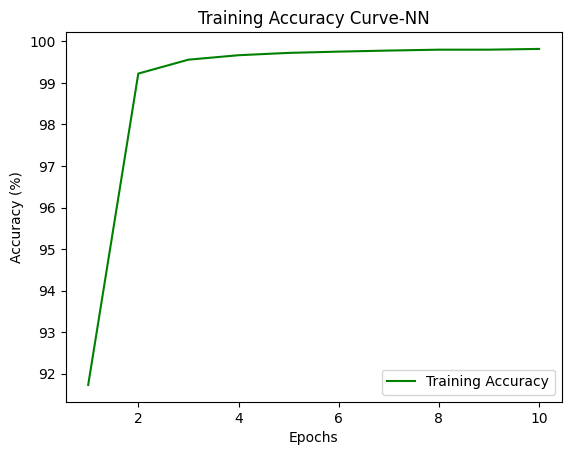

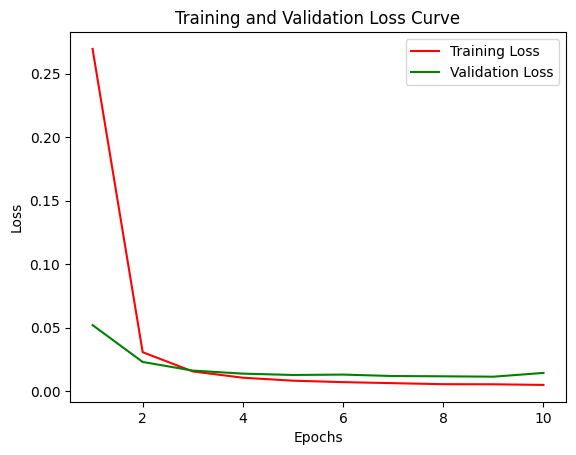

In [24]:
training_epochs=10
num_vessels = len(mmsi_encoder.classes_)
assert X_mmsi_train_t.min() >= 0
assert X_mmsi_train_t.max() < num_vessels
assert X_mmsi_val_t.min() >= 0
assert X_mmsi_val_t.max() < num_vessels
net_nn=Model(num_vessels,16,15)
optimizer = torch.optim.Adam(net_nn.parameters(), lr=1e-3)
net_nn = Model(num_vessels, embedding_dim, 15)
optimizer = torch.optim.Adam(net_nn.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

train_losses=[]
accuracies=[]
val_losses=[]
for epoch in range(training_epochs):  
    running_loss = 0.0
    net_nn.train()
    train_accuracy=0
    train_total=0
    train_correct=0
    for mmsi, numeric, labels in train_dataloader:
        optimizer.zero_grad()
        outputs = net_nn(mmsi,numeric)
        #print(mmsi)
        #print(numeric)
        labels = labels.long()
        #print(labels)
        criterion=nn.CrossEntropyLoss()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        predicted = outputs.argmax(dim=1)
        #print(predicted)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        running_loss += loss.item()
    #print(running_loss)
    train_losses.append(running_loss/len(train_dataloader))
    print(f"Epoch {epoch+1}/{training_epochs}, Loss: {running_loss/len(train_dataloader):.4f}")
    train_accuracy = 100 * train_correct / train_total
    accuracies.append(train_accuracy)
    all_val_labels = []
    all_val_predictions = []
    val_total=0
    val_correct=0
    val_accuracy=0
    val_running_loss=0
    with torch.no_grad():
        val_total=0
        val_correct=0
        val_accuracy=0
        running_loss=0.0
        for mmsi_val, numeric_val, labels_val in val_dataloader:
            net_nn.eval()
            outputs_val = net_nn(mmsi_val,numeric_val) 
            labels_val = labels_val.long()
            predicted_val = outputs_val.argmax(dim=1)
            all_val_labels.extend(labels_val.cpu().numpy())
            all_val_predictions.extend(predicted_val.cpu().numpy())
            val_total += labels_val.size(0)
            loss = criterion(outputs_val, labels_val)
            val_running_loss += loss.item()
            val_correct += (predicted_val == labels_val).sum().item()
        val_accuracy = 100 * val_correct / val_total
        val_losses.append(val_running_loss/len(val_dataloader))
    print(f"Val Accuracy: {val_accuracy:.2f}%")
print('Finished Training')

#Next we evaluate the RNN model quickly
plt.plot(range(1, training_epochs + 1), accuracies, label="Training Accuracy", color="green")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy Curve-NN")
plt.legend()
plt.savefig('accuracy_graph_nn.png')
plt.show()
plt.plot(range(1, training_epochs + 1), train_losses, label="Training Loss", color="red")
plt.plot(range(1, training_epochs + 1), val_losses, label="Validation Loss", color="green")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curve")
plt.legend()
plt.savefig('Loss_graph_NN.png')
plt.show()

Test Accuracy: 99.72%


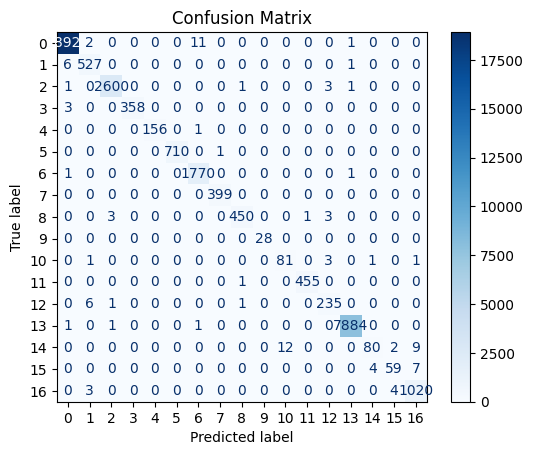

In [25]:
net_nn.eval()
test_total=0
test_correct=0
test_accuracy=0
all_test_labels = []
all_test_predictions = []
test_accuracies=[]
with torch.no_grad():
    for mmsi, numeric, labels in test_dataloader:
            outputs = net_nn(mmsi,numeric) 
            labels = labels.long()
            predicted = outputs.argmax(dim=1)
            all_test_labels.extend(labels.cpu().numpy())
            all_test_predictions.extend(predicted.cpu().numpy())
            test_total += labels.size(0)
            running_loss += loss.item()
            test_correct += (predicted == labels).sum().item()
        
    accuracy = 100 * test_correct / test_total
    print(f"Test Accuracy: {accuracy:.2f}%")
    test_accuracies.append(test_accuracy)
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    import matplotlib.pyplot as plt
    
    cm = confusion_matrix(all_test_labels, all_test_predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.show()

    

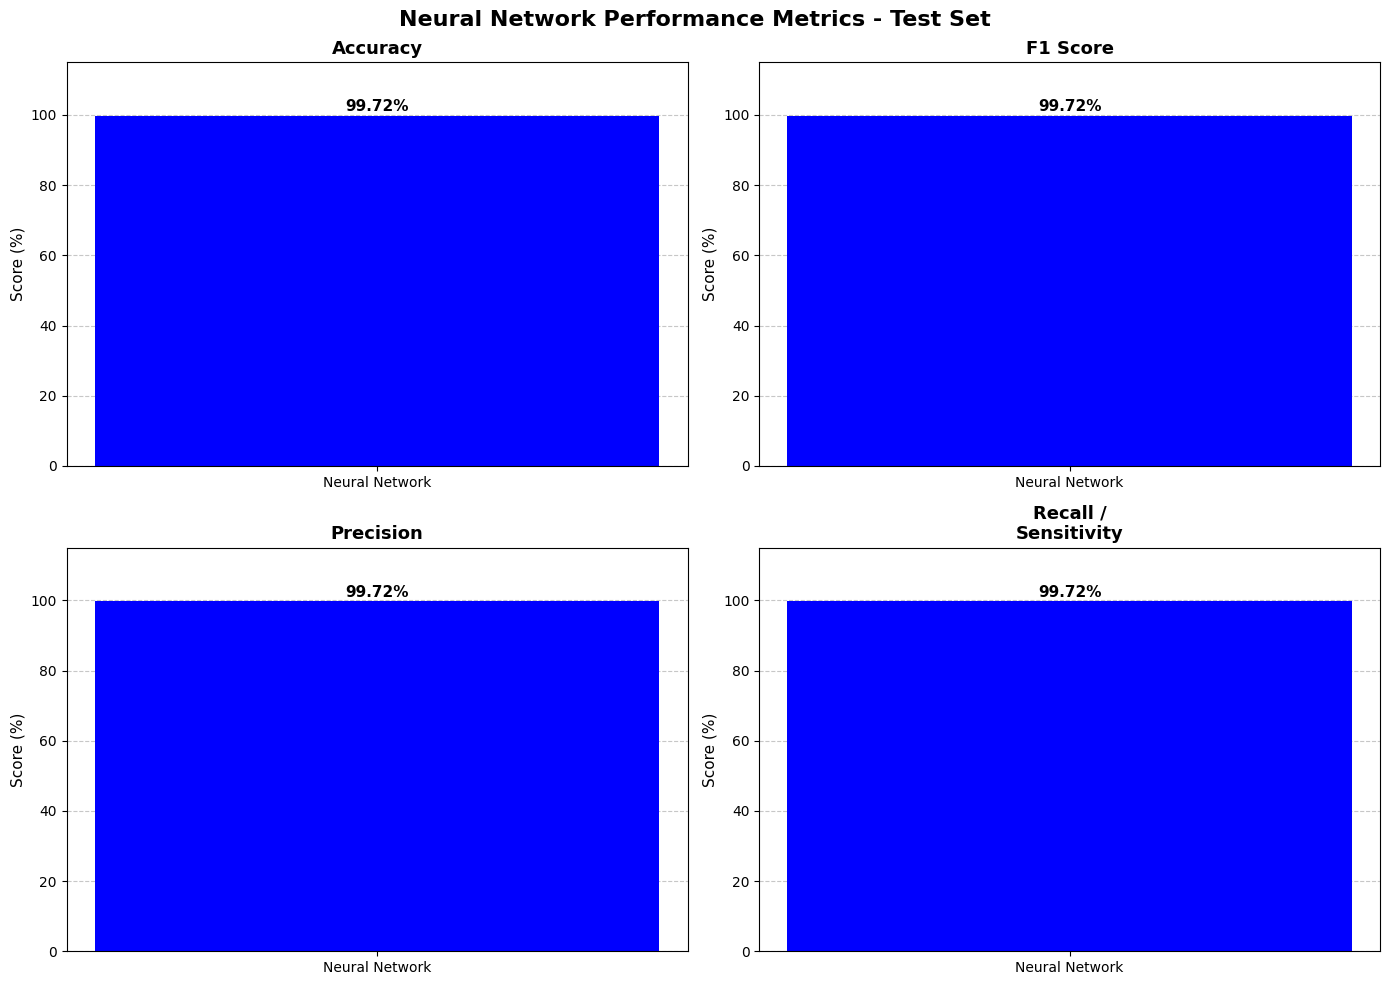

In [27]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import matplotlib.pyplot as plt

# all_test_labels and all_test_predictions already collected in your test loop
models = ['Neural Network']
bar_colors = ['blue']

metrics = {
    'Accuracy':  [accuracy_score(all_test_labels, all_test_predictions) * 100],
    'F1 Score':  [f1_score(all_test_labels, all_test_predictions, average='weighted') * 100],
    'Precision': [precision_score(all_test_labels, all_test_predictions, average='weighted', zero_division=0) * 100],
    'Recall /\nSensitivity': [recall_score(all_test_labels, all_test_predictions, average='weighted', zero_division=0) * 100],
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (metric_name, values) in zip(axes, metrics.items()):
    bars = ax.bar(models, values, color=bar_colors, width=0.3)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_title(metric_name, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score (%)', fontsize=11)
    ax.set_ylim(0, 115)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

plt.suptitle('Neural Network Performance Metrics - Test Set', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(feature_dataset,
    shipType, test_size=0.2, random_state=42)
X_train, X_val,y_train, y_val = sk.model_selection.train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    shuffle=True
)

from sklearn import svm

svm = svm.SVC(kernel='rbf')
svm.fit(X_train, y_train)
from sklearn.metrics import accuracy_score
SVM_val_preds = svm.predict(X_val)
print(f"Val Accuracy: {accuracy_score(y_val, SVM_val_preds) * 100:.2f}%")

#Random Forest
RF=sklearn.ensemble.RandomForestClassifier()
RF.fit(X_train,y_train)
RF_val_preds=RF.predict(X_val)
print(f"Val Accuracy: {accuracy_score(y_val, RF_val_preds) * 100:.2f}%")


#Decision Tree
DT= sklearn.tree.DecisionTreeClassifier()
DT.fit(X_train,y_train)
DT_val_preds=DT.predict(X_val)
print(f"Val Accuracy: {accuracy_score(y_val, DT_val_preds) * 100:.2f}%")



#K-NN
KNN=sklearn.neighbors.KNeighborsClassifier()
KNN.fit(X_train,y_train)
KNN_val_preds=KNN.predict(X_val)
print(f"Val Accuracy: {accuracy_score(y_val, KNN_val_preds) * 100:.2f}%")

Val Accuracy: 71.91%
Val Accuracy: 97.63%
Val Accuracy: 97.87%
Val Accuracy: 91.60%


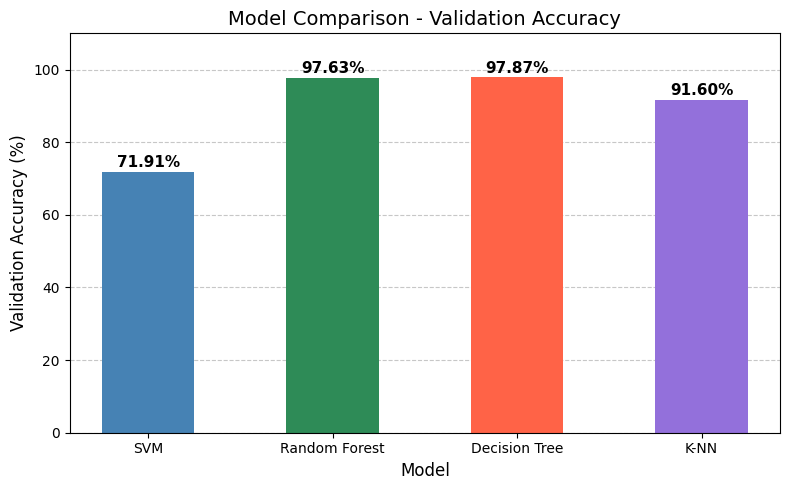

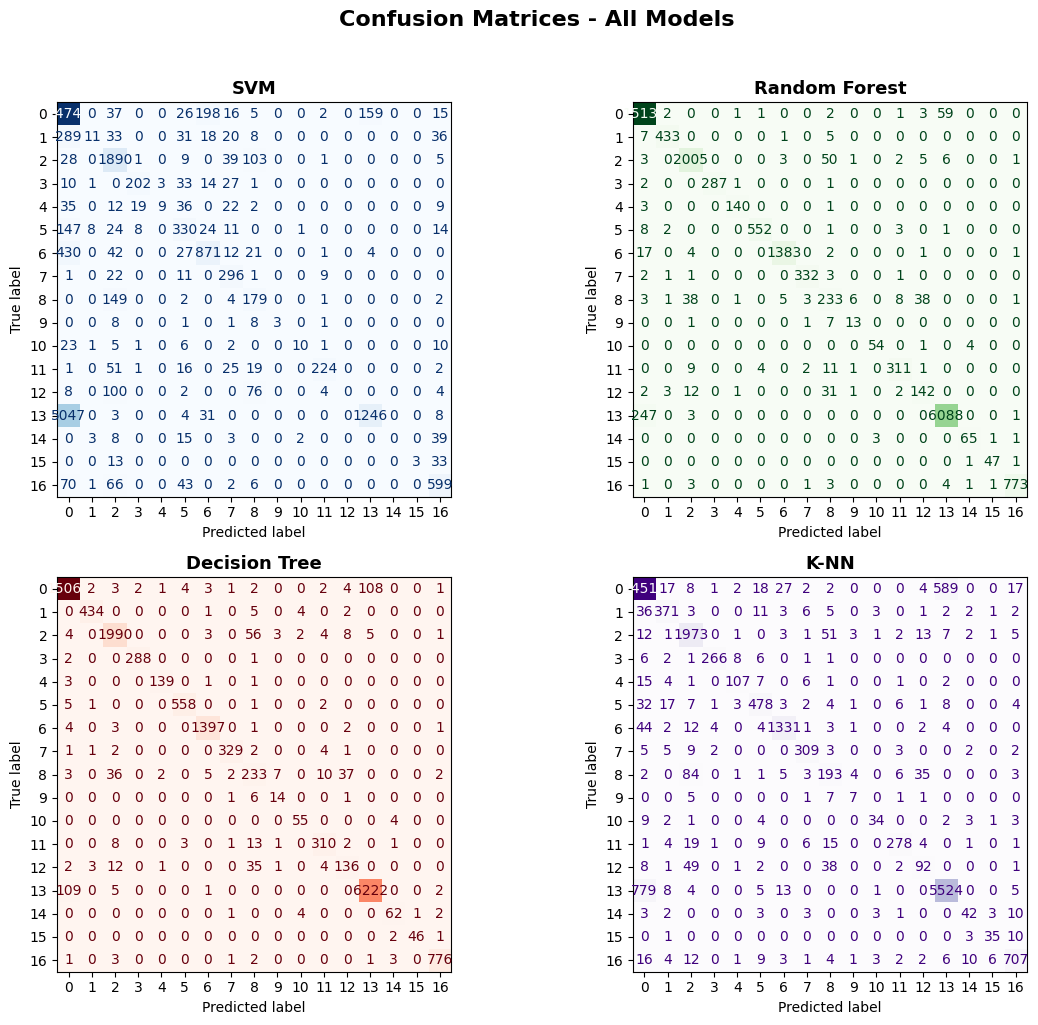

In [9]:
#Accuracy Bar Graphs
models = ['SVM', 'Random Forest', 'Decision Tree', 'K-NN']
preds = [SVM_val_preds, RF_val_preds, DT_val_preds, KNN_val_preds]
accuracies = [accuracy_score(y_val, p) * 100 for p in preds]

# Plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, accuracies, color=['steelblue', 'seagreen', 'tomato', 'mediumpurple'], width=0.5)

# Add value labels on top of each bar
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax.set_title('Model Comparison - Validation Accuracy', fontsize=14)
ax.set_ylim(0, 110)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


#Confusion Matrices
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = ['SVM', 'Random Forest', 'Decision Tree', 'K-NN']
preds = [SVM_val_preds, RF_val_preds, DT_val_preds, KNN_val_preds]
colors = ['Blues', 'Greens', 'Reds', 'Purples']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, model_name, pred, cmap in zip(axes, models, preds, colors):
    cm = confusion_matrix(y_val, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f'{model_name}', fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

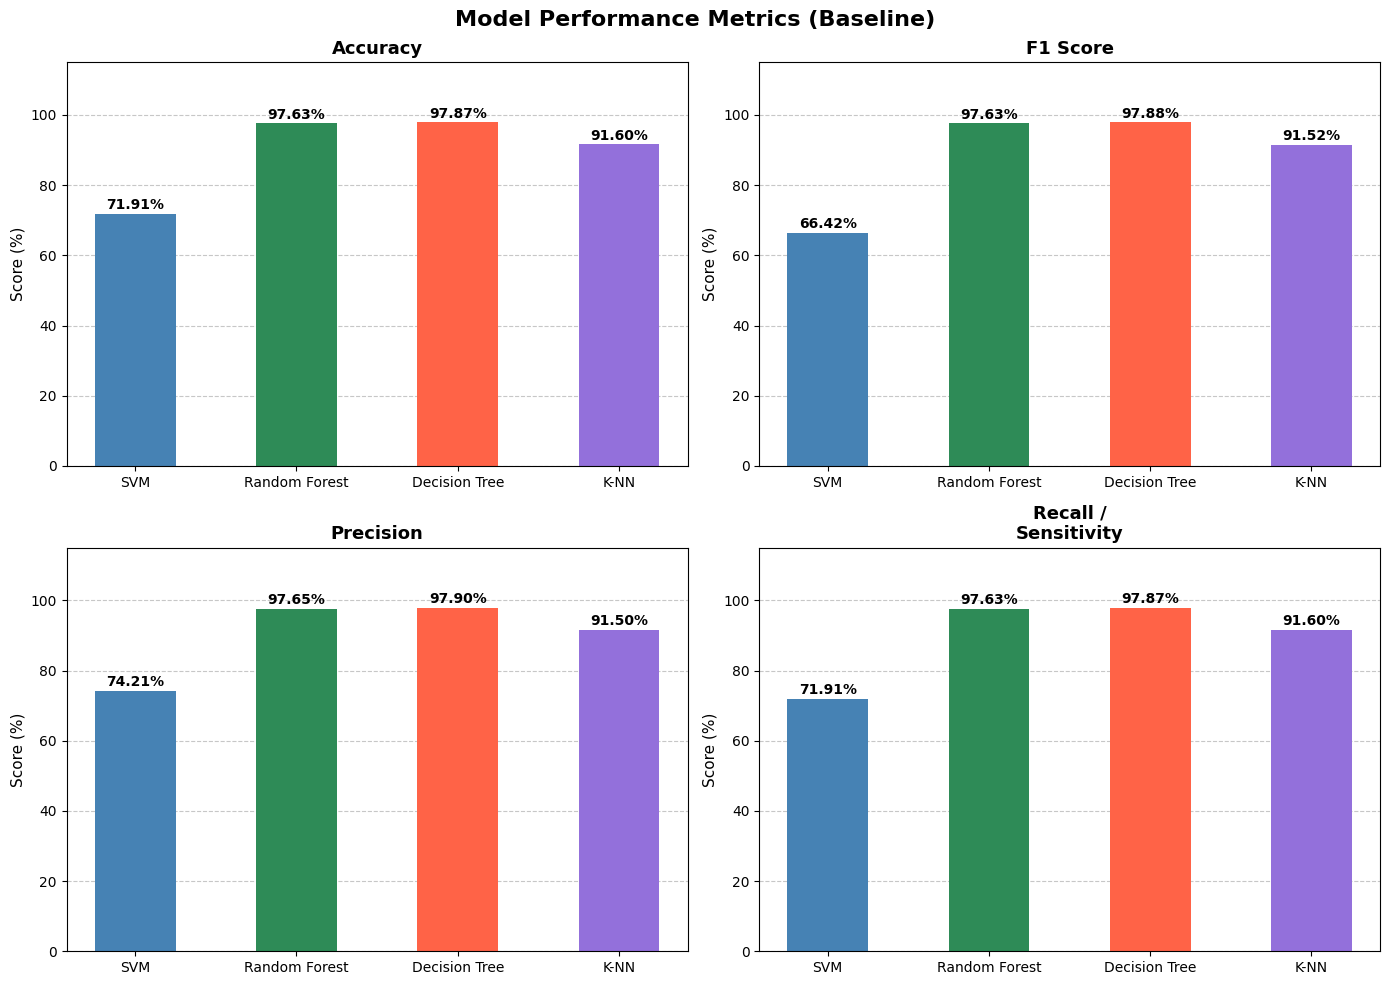

In [19]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

models = ['SVM', 'Random Forest', 'Decision Tree', 'K-NN']
preds = [SVM_val_preds, RF_val_preds, DT_val_preds, KNN_val_preds]
bar_colors = ['steelblue', 'seagreen', 'tomato', 'mediumpurple']

# Compute metrics for each model (weighted average for multiclass)
metrics = {
    'Accuracy':  [accuracy_score(y_val, p) * 100 for p in preds],
    'F1 Score':  [f1_score(y_val, p, average='weighted') * 100 for p in preds],
    'Precision': [precision_score(y_val, p, average='weighted', zero_division=0) * 100 for p in preds],
    'Recall /\nSensitivity': [recall_score(y_val, p, average='weighted', zero_division=0) * 100 for p in preds],
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (metric_name, values) in zip(axes, metrics.items()):
    bars = ax.bar(models, values, color=bar_colors, width=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(metric_name, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score (%)', fontsize=11)
    ax.set_ylim(0, 115)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

plt.suptitle('Model Performance Metrics (Baseline)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

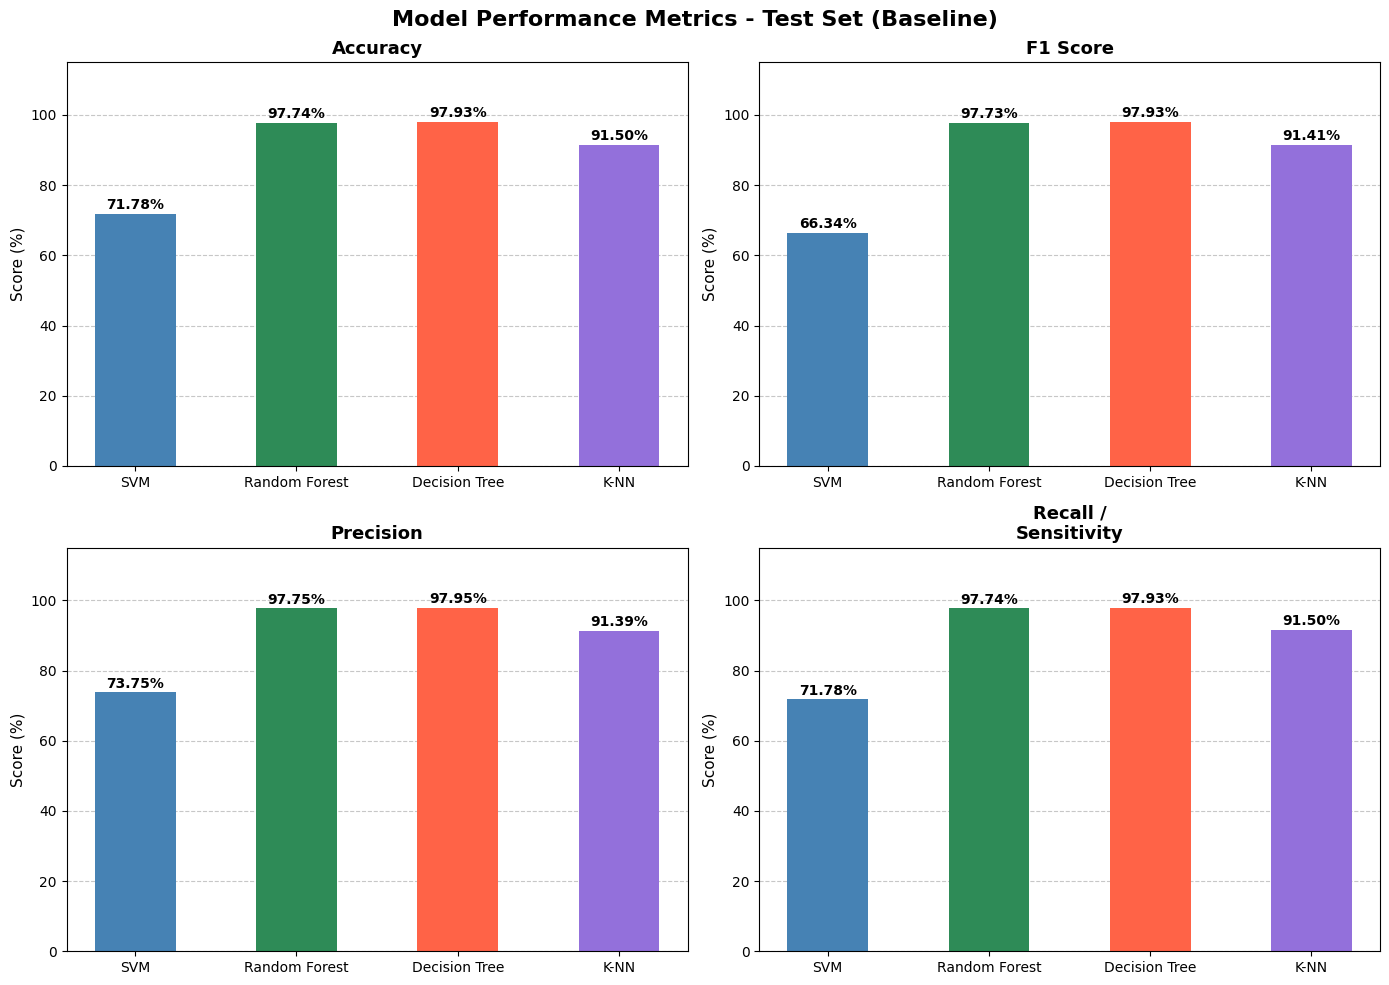

In [20]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

models = ['SVM', 'Random Forest', 'Decision Tree', 'K-NN']
bar_colors = ['steelblue', 'seagreen', 'tomato', 'mediumpurple']

# Generate test set predictions
SVM_test_preds = svm.predict(X_test)
RF_test_preds = RF.predict(X_test)
DT_test_preds = DT.predict(X_test)
KNN_test_preds = KNN.predict(X_test)

test_preds = [SVM_test_preds, RF_test_preds, DT_test_preds, KNN_test_preds]

# Compute metrics
metrics = {
    'Accuracy':  [accuracy_score(y_test, p) * 100 for p in test_preds],
    'F1 Score':  [f1_score(y_test, p, average='weighted') * 100 for p in test_preds],
    'Precision': [precision_score(y_test, p, average='weighted', zero_division=0) * 100 for p in test_preds],
    'Recall /\nSensitivity': [recall_score(y_test, p, average='weighted', zero_division=0) * 100 for p in test_preds],
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (metric_name, values) in zip(axes, metrics.items()):
    bars = ax.bar(models, values, color=bar_colors, width=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(metric_name, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score (%)', fontsize=11)
    ax.set_ylim(0, 115)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

plt.suptitle('Model Performance Metrics - Test Set (Baseline)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
X_train_feature, X_test_feature, y_train_feature, y_test_feature =sk.model_selection.train_test_split(feature_dataset,
    shipType, test_size=0.2, random_state=42)


X_train_feature, X_val_feature,y_train_feature, y_val_feature = sk.model_selection.train_test_split(
    X_train_feature,
    y_train_feature,
    test_size=0.1,
    shuffle=True
)
#Next we load this in a dataloader
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train_feature)
y_val_enc   = le.transform(y_val_feature)
y_test_enc=le.transform(y_test_feature)
#Next we need to feed these into the basic pytorch model

X_feature_train_t = torch.tensor(X_train_feature.to_numpy(), dtype=torch.float32)
X_feature_val_t   = torch.tensor(X_val_feature.to_numpy(), dtype=torch.float32)
X_feature_test_t=torch.tensor(X_test_feature.to_numpy(),dtype=torch.float32)
y_train_t = torch.tensor(y_train_enc, dtype=torch.long)
y_val_t   = torch.tensor(y_val_enc, dtype=torch.long)
y_test_t=torch.tensor(y_test_enc,dtype=torch.long)
feature_train_dataset = TensorDataset(
    X_feature_train_t,
    y_train_t
)

feature_val_dataset = TensorDataset(
    X_feature_val_t,
    y_val_t
)
feature_test_dataset=TensorDataset(X_feature_test_t,y_test_t)
feature_train_dataloader = DataLoader(feature_train_dataset, batch_size=32, shuffle=True)
feature_val_dataloader   = DataLoader(feature_val_dataset, batch_size=32, shuffle=True)
feature_test_dataloader=DataLoader(feature_test_dataset,batch_size=32,shuffle=True)

In [11]:
class Simple_Model(nn.Module):
    def __init__(self, num_numeric_features):
        super().__init__()

        self.input_dim = num_numeric_features
        
        self.fc1 = nn.Linear(self.input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 17)
        
    def forward(self,features):
        x=features
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.fc4(x) 
        return x

Epoch 1/20, Loss: 0.7424
Val Accuracy: 73.38%
Epoch 2/20, Loss: 0.6017
Val Accuracy: 72.16%
Epoch 3/20, Loss: 0.5611
Val Accuracy: 75.29%
Epoch 4/20, Loss: 0.5258
Val Accuracy: 77.21%
Epoch 5/20, Loss: 0.5004
Val Accuracy: 78.35%
Epoch 6/20, Loss: 0.4788
Val Accuracy: 79.44%
Epoch 7/20, Loss: 0.4614
Val Accuracy: 79.73%
Epoch 8/20, Loss: 0.4489
Val Accuracy: 79.94%
Epoch 9/20, Loss: 0.4379
Val Accuracy: 80.90%
Epoch 10/20, Loss: 0.4268
Val Accuracy: 80.83%
Epoch 11/20, Loss: 0.4187
Val Accuracy: 81.68%
Epoch 12/20, Loss: 0.4121
Val Accuracy: 81.73%
Epoch 13/20, Loss: 0.4050
Val Accuracy: 81.40%
Epoch 14/20, Loss: 0.3985
Val Accuracy: 82.82%
Epoch 15/20, Loss: 0.3936
Val Accuracy: 82.44%
Epoch 16/20, Loss: 0.3887
Val Accuracy: 82.24%
Epoch 17/20, Loss: 0.3834
Val Accuracy: 81.50%
Epoch 18/20, Loss: 0.3792
Val Accuracy: 82.58%
Epoch 19/20, Loss: 0.3759
Val Accuracy: 83.50%
Epoch 20/20, Loss: 0.3716
Val Accuracy: 82.04%
Finished Training


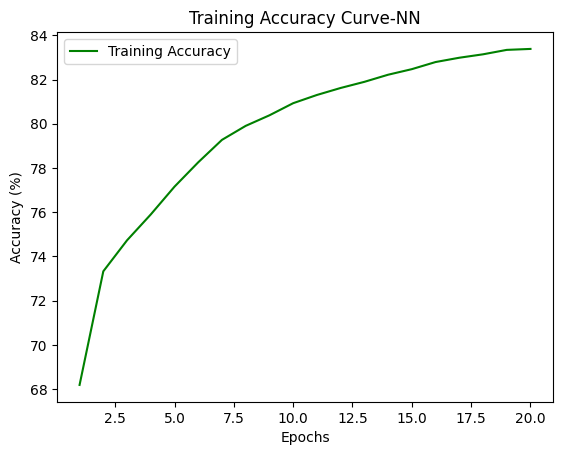

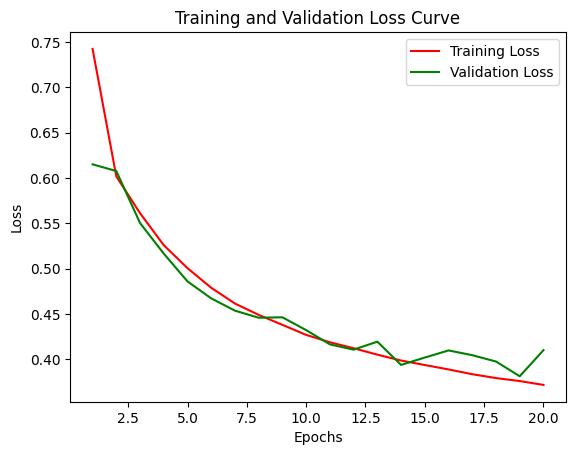

In [12]:
training_epochs=20
net_nns=Simple_Model(15)
optimizer = torch.optim.Adam(net_nns.parameters(), lr=1e-3)

train_losses=[]
accuracies=[]
val_losses=[]

for epoch in range(training_epochs):  
    running_loss = 0.0
    net_nns.train()
    train_accuracy=0
    train_total=0
    train_correct=0
    for inputs, labels in feature_train_dataloader:
        optimizer.zero_grad()
        outputs = net_nns(inputs)
        #print(mmsi)
        #print(numeric)
        labels = labels.long()
        #print(labels)
        criterion=nn.CrossEntropyLoss()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        predicted = outputs.argmax(dim=1)
        #print(predicted)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        running_loss += loss.item()
    #print(running_loss)
    train_losses.append(running_loss/len(train_dataloader))
    print(f"Epoch {epoch+1}/{training_epochs}, Loss: {running_loss/len(train_dataloader):.4f}")
    train_accuracy = 100 * train_correct / train_total
    accuracies.append(train_accuracy)
    all_val_labels = []
    all_val_predictions = []
    val_total=0
    val_correct=0
    val_accuracy=0
    val_running_loss=0
    with torch.no_grad():
        val_total=0
        val_correct=0
        val_accuracy=0
        running_loss=0.0
        for input, labels_val in feature_val_dataloader:
            net_nns.eval()
            outputs_val = net_nns(input) 
            labels_val = labels_val.long()
            predicted_val = outputs_val.argmax(dim=1)
            all_val_labels.extend(labels_val.cpu().numpy())
            all_val_predictions.extend(predicted_val.cpu().numpy())
            val_total += labels_val.size(0)
            loss = criterion(outputs_val, labels_val)
            val_running_loss += loss.item()
            val_correct += (predicted_val == labels_val).sum().item()
        val_accuracy = 100 * val_correct / val_total
        val_losses.append(val_running_loss/len(val_dataloader))
    print(f"Val Accuracy: {val_accuracy:.2f}%")
print('Finished Training')

#Next we evaluate the RNN model quickly
plt.plot(range(1, training_epochs + 1), accuracies, label="Training Accuracy", color="green")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy Curve-NN")
plt.legend()
plt.savefig('accuracy_graph_nn.png')
plt.show()
plt.plot(range(1, training_epochs + 1), train_losses, label="Training Loss", color="red")
plt.plot(range(1, training_epochs + 1), val_losses, label="Validation Loss", color="green")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curve")
plt.legend()
plt.savefig('Loss_graph_NN.png')
plt.show()

Test Accuracy: 82.33%


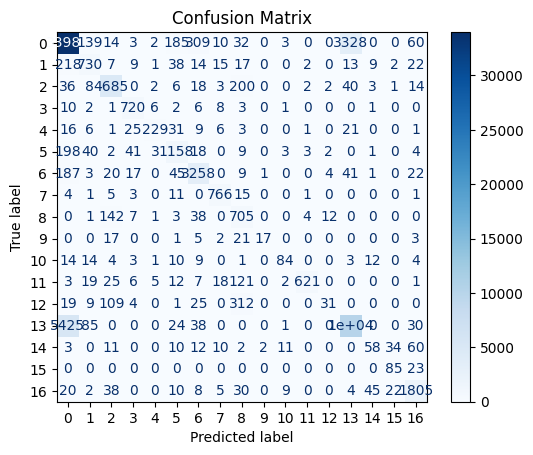

In [22]:
net_nns.eval()
test_total=0
test_correct=0
test_accuracy=0
all_test_labels = []
all_test_predictions = []
test_accuracies=[]
with torch.no_grad():
    for inputs, labels in feature_test_dataloader:
            outputs = net_nns(inputs) 
            labels = labels.long()
            predicted = outputs.argmax(dim=1)
            all_test_labels.extend(labels.cpu().numpy())
            all_test_predictions.extend(predicted.cpu().numpy())
            test_total += labels.size(0)
            running_loss += loss.item()
            test_correct += (predicted == labels).sum().item()
        
    accuracy = 100 * test_correct / test_total
    print(f"Test Accuracy: {accuracy:.2f}%")
    test_accuracies.append(test_accuracy)
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    import matplotlib.pyplot as plt
    
    cm = confusion_matrix(all_test_labels, all_test_predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.show()